# Chest X-Ray Pneumonia Detection Using ResNet50

## Project Overview

This project develops a binary deep learning model for detecting pneumonia from chest X-ray images using **ResNet50 transfer learning**.

The model classifies chest X-ray images into two categories:

- **NORMAL**
- **PNEUMONIA**

The project follows a complete image-classification workflow, including dataset exploration, preprocessing, transfer learning, controlled experiments, model evaluation, confusion-matrix analysis, training-curve analysis, and error analysis.

### Research Objective

The primary objective is to investigate whether a pretrained ResNet50 model can effectively distinguish pneumonia cases from normal chest X-ray images while examining the trade-off between **pneumonia sensitivity and false-positive predictions**.

Two training experiments were conducted:

- **Experiment 1:** ResNet50 with class-weighted CrossEntropyLoss
- **Experiment 2:** ResNet50 with standard CrossEntropyLoss

The experiments are compared using accuracy, precision, recall, and F1-score on the held-out test set.

### Final Model Finding

Experiment 1 achieved the stronger overall test performance:

| Metric | Experiment 1 |
|---|---:|
| Test Accuracy | 82.69% |
| Test Precision | 78.43% |
| Test Recall | 99.74% |
| Test F1-Score | 87.81% |

The model demonstrated **very high recall for pneumonia**, with only one pneumonia case classified as normal in the test set. However, it also produced a substantial number of false-positive predictions for normal X-rays. Therefore, the results indicate strong sensitivity toward pneumonia cases but a limitation in distinguishing normal cases from pneumonia.

> **Important:** This project is intended for research and educational purposes. It is not a clinical diagnostic system and should not be used for medical decision-making.

## 1. Imports and Reproducible Setup

In [1]:
import os
import copy
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Device: cuda
CUDA version: 12.8
GPU: Tesla T4


## 2. Dataset

The project uses the **Chest X-Ray Pneumonia** dataset, containing chest X-ray images organized into two binary classification categories:

- **NORMAL**
- **PNEUMONIA**

The dataset is organized into separate training, validation, and test directories.

### Dataset Structure

```text
chest_xray/
├── train/
│   ├── NORMAL/
│   └── PNEUMONIA/
├── val/
│   ├── NORMAL/
│   └── PNEUMONIA/
└── test/
    ├── NORMAL/
    └── PNEUMONIA/
### Original Dataset Distribution

| Split      | NORMAL | PNEUMONIA | Total |
|------------|-------:|----------:|------:|
| Training   | 1,341  | 3,875     | 5,216 |
| Validation | 8      | 8         | 16    |
| Test       | 234    | 390       | 624   |



In [2]:
base_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

print("Dataset path:")
print(base_path)

print("\nFolders:")
print(os.listdir(base_path))

for split in ["train", "val", "test"]:
    print(split, "->", os.listdir(os.path.join(base_path, split)))

Dataset path:
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray

Folders:
['chest_xray', '__MACOSX', 'val', 'test', 'train']
train -> ['PNEUMONIA', 'NORMAL']
val -> ['PNEUMONIA', 'NORMAL']
test -> ['PNEUMONIA', 'NORMAL']


## 3. Class Distribution

The class distribution is examined to understand the balance between the **NORMAL** and **PNEUMONIA** categories across the dataset splits.

The original training set contains substantially more pneumonia images than normal images, creating a notable class imbalance:

- **NORMAL:** 1,341 images
- **PNEUMONIA:** 3,875 images

The validation split initially contains only 16 images, while the test set contains 624 images.

This class imbalance is an important consideration during model development because a classifier may become biased toward the majority **PNEUMONIA** class. To address this during experimentation, **Experiment 1 uses class-weighted CrossEntropyLoss**.

The class distribution is visualized below to provide a clear overview of the dataset composition before model training.

In [3]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")

    for class_name in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(base_path, split, class_name)

        images = [
            file for file in os.listdir(folder)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{class_name}: {len(images)} images")


TRAIN
NORMAL: 1341 images
PNEUMONIA: 3875 images

VAL
NORMAL: 8 images
PNEUMONIA: 8 images

TEST
NORMAL: 234 images
PNEUMONIA: 390 images


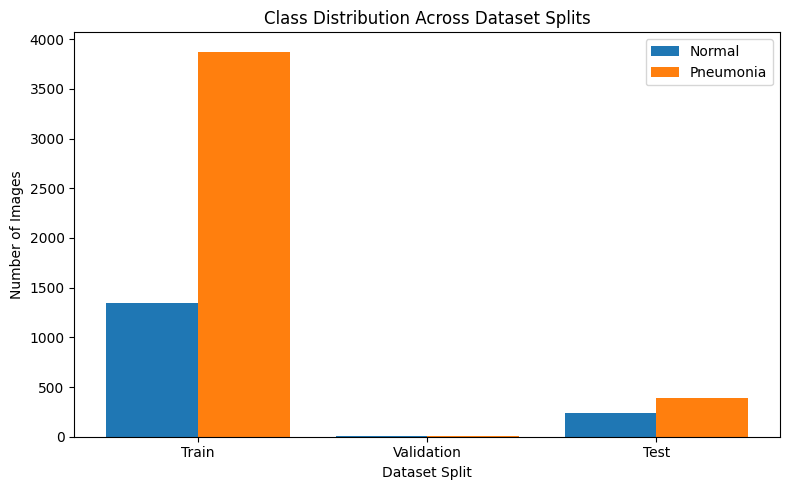

In [4]:
splits = ["Train", "Validation", "Test"]
normal_counts = [1341, 8, 234]
pneumonia_counts = [3875, 8, 390]

x = np.arange(len(splits))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, normal_counts, width=0.4, label="Normal")
plt.bar(x + 0.2, pneumonia_counts, width=0.4, label="Pneumonia")

plt.xticks(x, splits)
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.title("Class Distribution Across Dataset Splits")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Sample X-Ray Visualization and Image Properties

Representative chest X-ray images from the **NORMAL** and **PNEUMONIA** classes are visualized to understand the appearance and variability of the input data.

This step provides a qualitative inspection of the dataset before preprocessing and model training.

### Image Characteristics

The analysis also examines basic image properties, including:

- Image dimensions and resolution.
- Grayscale intensity distribution.
- Pixel-level mean and standard deviation.
- Differences in image characteristics between training and test samples.

A sample of images is used for this analysis rather than processing the entire dataset, since the objective is to obtain a representative overview while keeping exploratory analysis computationally efficient.

These observations help guide the subsequent preprocessing and normalization steps used by the ResNet50 model.

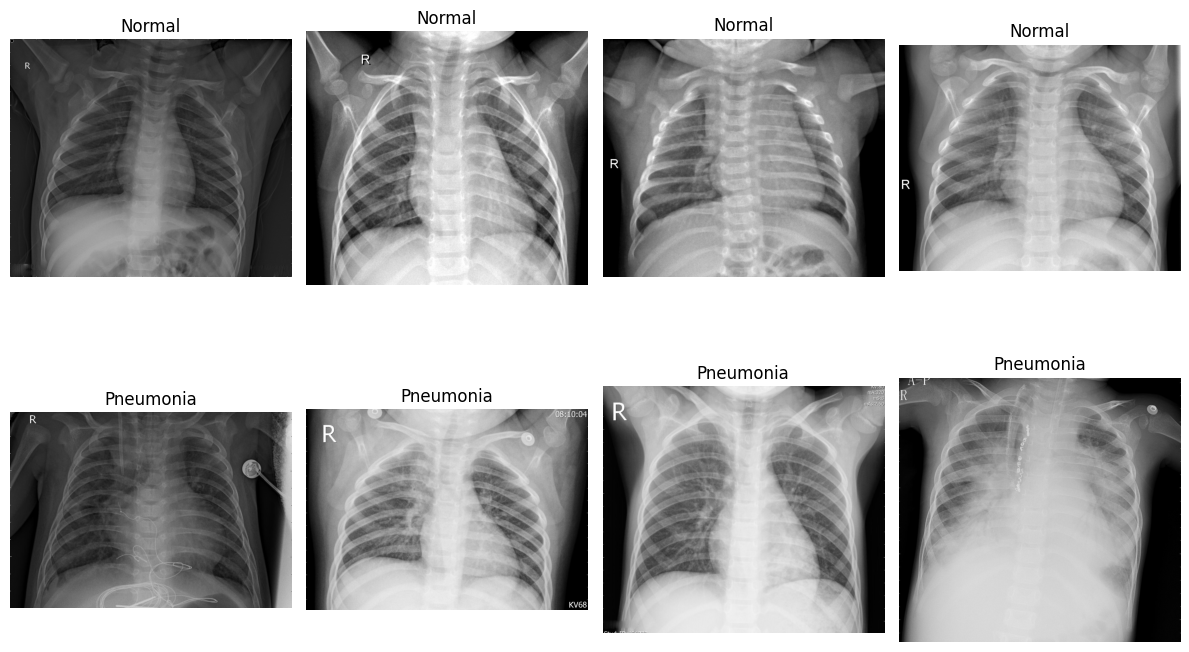

In [5]:
normal_path = os.path.join(base_path, "train", "NORMAL")
pneumonia_path = os.path.join(base_path, "train", "PNEUMONIA")

normal_images = os.listdir(normal_path)
pneumonia_images = os.listdir(pneumonia_path)

plt.figure(figsize=(12, 8))

for i in range(4):
    image = Image.open(os.path.join(normal_path, normal_images[i]))
    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title("Normal")
    plt.axis("off")

for i in range(4):
    image = Image.open(os.path.join(pneumonia_path, pneumonia_images[i]))
    plt.subplot(2, 4, i + 5)
    plt.imshow(image, cmap="gray")
    plt.title("Pneumonia")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
normal = Image.open(os.path.join(normal_path, normal_images[0]))
pneumonia = Image.open(os.path.join(pneumonia_path, pneumonia_images[0]))

print("Normal image:")
print("Size:", normal.size)
print("Mode:", normal.mode)

print("\nPneumonia image:")
print("Size:", pneumonia.size)
print("Mode:", pneumonia.mode)

Normal image:
Size: (1336, 1128)
Mode: L

Pneumonia image:
Size: (1024, 712)
Mode: L


## 5. Image Transformations

Before being provided to ResNet50, the chest X-ray images are transformed into a format compatible with the pretrained model.

The preprocessing pipeline includes:

- Resizing images to a consistent spatial resolution.
- Converting grayscale X-ray images to the required input format for ResNet50.
- Converting images to tensors.
- Applying normalization using the preprocessing expected by the pretrained ResNet50 model.

These transformations ensure that all images have a consistent representation and can be processed efficiently by the neural network.

The same preprocessing principles are applied consistently during training, validation, and testing to ensure that the model is evaluated on data represented in a compatible format.

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training and validation/test transformations created.")

Training and validation/test transformations created.


## 6. DataLoaders

PyTorch `DataLoader` objects are used to efficiently load the processed images in mini-batches during model training, validation, and testing.

The DataLoaders provide:

- Efficient batch-wise data loading.
- Shuffling of the training data.
- Separate data pipelines for training, validation, and testing.
- Compatibility with GPU-based model training.

The training data is shuffled to reduce the effect of the original ordering of the images, while validation and test data are evaluated without training-time shuffling.

These DataLoaders provide the input pipeline used by the ResNet50 model in the subsequent training experiments.

In [8]:
train_dataset = ImageFolder(
    root=f"{base_path}/train",
    transform=train_transform
)

val_dataset = ImageFolder(
    root=f"{base_path}/val",
    transform=val_test_transform
)

test_dataset = ImageFolder(
    root=f"{base_path}/test",
    transform=val_test_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Class names:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

Training images: 5216
Validation images: 16
Test images: 624
Class names: ['NORMAL', 'PNEUMONIA']
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [9]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 163
Validation batches: 1
Test batches: 20


In [10]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels)
print("Pixel value range:", images.min().item(), "to", images.max().item())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1])
Pixel value range: -2.1179039478302 to 2.640000104904175


## 7. Train/Validation Split

The original training set contains 5,216 images, while the provided validation set contains only 16 images. Because the original validation set is too small for reliable model selection, a new validation subset is created from the original training data.

A **stratified 80/20 split** is used so that the relative proportions of the **NORMAL** and **PNEUMONIA** classes are maintained across the training and validation subsets.

### Split Strategy

- **80%** of the original training data is used for model training.
- **20%** is used for validation.
- Stratification preserves the class distribution in both subsets.
- The original test set remains completely separate and is not used during training or model selection.

This approach provides a more representative validation set while preserving the independent test set for final performance evaluation.

In [11]:
all_samples = train_dataset.samples

image_paths = [sample[0] for sample in all_samples]
labels = [sample[1] for sample in all_samples]

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("New training images:", len(train_paths))
print("New validation images:", len(val_paths))

print("\nTraining class distribution:")
print("NORMAL:", train_labels.count(0))
print("PNEUMONIA:", train_labels.count(1))

print("\nValidation class distribution:")
print("NORMAL:", val_labels.count(0))
print("PNEUMONIA:", val_labels.count(1))

New training images: 4172
New validation images: 1044

Training class distribution:
NORMAL: 1073
PNEUMONIA: 3099

Validation class distribution:
NORMAL: 268
PNEUMONIA: 776


In [12]:
class ChestXRayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("L")
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label


new_train_dataset = ChestXRayDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

new_val_dataset = ChestXRayDataset(
    val_paths,
    val_labels,
    transform=val_test_transform
)

new_train_loader = DataLoader(
    new_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

new_val_loader = DataLoader(
    new_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("New training dataset:", len(new_train_dataset))
print("New validation dataset:", len(new_val_dataset))
print("Training batches:", len(new_train_loader))
print("Validation batches:", len(new_val_loader))
print("Test batches:", len(test_loader))

New training dataset: 4172
New validation dataset: 1044
Training batches: 131
Validation batches: 33
Test batches: 20


## 8. Model Architecture — ResNet50 Transfer Learning

The project uses **ResNet50**, a deep convolutional neural network pretrained on the ImageNet dataset.

Instead of training the entire network from random initialization, **transfer learning** is used. The pretrained ResNet50 feature extractor provides a strong starting point for learning visual representations from the chest X-ray images.

### Architecture Adaptation

The original ResNet50 classification head is replaced with a new fully connected layer designed for the binary classification task:

- **Input:** Preprocessed chest X-ray image
- **Backbone:** Pretrained ResNet50
- **Feature extraction:** Convolutional layers of ResNet50
- **Classification head:** Adapted for two classes
- **Output classes:** NORMAL and PNEUMONIA

### Why ResNet50?

ResNet50 uses residual connections that allow information and gradients to propagate effectively through a deep neural network. Its pretrained visual representations make it suitable for transfer learning when working with a medical image dataset of limited size.

The same ResNet50 architecture is used for both experiments so that the experiments primarily compare the training configurations rather than different model architectures.

In [13]:
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

model.fc = nn.Linear(
    in_features=2048,
    out_features=2
)

model = model.to(device)

print("ResNet50 loaded successfully.")
print("Final layer:", model.fc)
print("Model is using:", device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


ResNet50 loaded successfully.
Final layer: Linear(in_features=2048, out_features=2, bias=True)
Model is using: cuda


## 9. Experiment 1 — Class-Weighted Training

The first experiment evaluates ResNet50 transfer learning using a **class-weighted CrossEntropyLoss**.

Because the training dataset contains substantially more **PNEUMONIA** images than **NORMAL** images, class weighting is used to reduce the effect of this imbalance during optimization.

### Objective

The purpose of Experiment 1 is to encourage the model to pay greater attention to the minority **NORMAL** class while maintaining strong detection of pneumonia cases.

### Evaluation Metrics

The experiment is evaluated using:

- **Accuracy** — overall proportion of correctly classified test images.
- **Precision** — proportion of predicted pneumonia cases that are actually pneumonia.
- **Recall** — proportion of actual pneumonia cases correctly detected.
- **F1-score** — harmonic mean of precision and recall.

The held-out test set is used only after training to measure the final performance of the experiment.

In [14]:
normal_count = train_labels.count(0)
pneumonia_count = train_labels.count(1)

total = normal_count + pneumonia_count
num_classes = 2

normal_weight = total / (num_classes * normal_count)
pneumonia_weight = total / (num_classes * pneumonia_count)

class_weights = torch.tensor(
    [normal_weight, pneumonia_weight],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

print("Class weights:")
print("NORMAL:", normal_weight)
print("PNEUMONIA:", pneumonia_weight)
print("Weighted CrossEntropyLoss, optimizer, and scheduler created.")

Class weights:
NORMAL: 1.9440820130475303
PNEUMONIA: 0.6731203614069055
Weighted CrossEntropyLoss, optimizer, and scheduler created.


## 10. Training and Evaluation Functions

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(
        all_labels, all_predictions,
        pos_label=1, zero_division=0
    )
    recall = recall_score(
        all_labels, all_predictions,
        pos_label=1, zero_division=0
    )
    f1 = f1_score(
        all_labels, all_predictions,
        pos_label=1, zero_division=0
    )

    return epoch_loss, accuracy, precision, recall, f1


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(
        all_labels, all_predictions,
        pos_label=1, zero_division=0
    )
    recall = recall_score(
        all_labels, all_predictions,
        pos_label=1, zero_division=0
    )
    f1 = f1_score(
        all_labels, all_predictions,
        pos_label=1, zero_division=0
    )

    return epoch_loss, accuracy, precision, recall, f1

In [16]:
num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": []
}

best_val_f1 = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    train_loss, train_acc, train_precision, train_recall, train_f1 = train_one_epoch(
        model, new_train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model, new_val_loader, criterion, device
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)
    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)
    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_weights = copy.deepcopy(model.state_dict())

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"LR: {current_lr:.6f}"
    )

Epoch [1/10] | Train Loss: 0.1903 | Val Loss: 0.0812 | Train F1: 0.9492 | Val F1: 0.9661 | Val Recall: 0.9356 | LR: 0.000100
Epoch [2/10] | Train Loss: 0.0857 | Val Loss: 0.0605 | Train F1: 0.9804 | Val F1: 0.9763 | Val Recall: 0.9575 | LR: 0.000100
Epoch [3/10] | Train Loss: 0.0554 | Val Loss: 0.0481 | Train F1: 0.9862 | Val F1: 0.9903 | Val Recall: 0.9884 | LR: 0.000100
Epoch [4/10] | Train Loss: 0.0437 | Val Loss: 0.0370 | Train F1: 0.9898 | Val F1: 0.9890 | Val Recall: 0.9820 | LR: 0.000100
Epoch [5/10] | Train Loss: 0.0445 | Val Loss: 0.0368 | Train F1: 0.9880 | Val F1: 0.9864 | Val Recall: 0.9794 | LR: 0.000100
Epoch [6/10] | Train Loss: 0.0478 | Val Loss: 0.0623 | Train F1: 0.9867 | Val F1: 0.9891 | Val Recall: 0.9948 | LR: 0.000100
Epoch [7/10] | Train Loss: 0.0271 | Val Loss: 0.0425 | Train F1: 0.9942 | Val F1: 0.9836 | Val Recall: 0.9691 | LR: 0.000100
Epoch [8/10] | Train Loss: 0.0199 | Val Loss: 0.0295 | Train F1: 0.9943 | Val F1: 0.9942 | Val Recall: 0.9923 | LR: 0.000100


## 11. Experiment 1 — Final Test Evaluation

After training, Experiment 1 is evaluated on the **held-out test set** containing 624 chest X-ray images.

The test set is kept separate from the training and validation process and is used to estimate the model's final performance on unseen data.

### Test Performance

| Metric | Experiment 1 |
|---|---:|
| Test Loss | 0.6628 |
| Test Accuracy | 82.69% |
| Test Precision | 78.43% |
| Test Recall | 99.74% |
| Test F1-Score | 87.81% |

### Interpretation

The model achieves **very high pneumonia recall (99.74%)**, indicating that it successfully identifies almost all pneumonia cases in the test set.

However, the precision of **78.43%** and the confusion matrix indicate that the model produces a considerable number of false-positive predictions for NORMAL images.

Therefore, the results demonstrate a clear trade-off:

- **Strength:** Very high sensitivity to pneumonia cases.
- **Limitation:** Relatively weaker discrimination of normal cases.
- **Overall:** Experiment 1 provides the stronger performance of the two experiments based on test accuracy and F1-score.

These results should be interpreted in the context of the dataset's class imbalance and the limitations discussed later in this notebook.

In [17]:
model.load_state_dict(best_model_weights)

test_loss, test_accuracy, test_precision, test_recall, test_f1 = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("FINAL TEST RESULTS")
print("-------------------")
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")

FINAL TEST RESULTS
-------------------
Test Loss:      0.7032
Test Accuracy:  0.8429
Test Precision: 0.8004
Test Recall:    0.9974
Test F1-Score:  0.8881


## 12. Experiment 1 — Confusion Matrix and Classification Report

The confusion matrix provides a detailed view of how Experiment 1 classified the images in the held-out test set.

For this binary classification task, the matrix is interpreted as follows:

| | Predicted NORMAL | Predicted PNEUMONIA |
|---|---:|---:|
| **Actual NORMAL** | 127 | 107 |
| **Actual PNEUMONIA** | 1 | 389 |

### Interpretation

The model correctly classified:

- **127 NORMAL** images.
- **389 PNEUMONIA** images.

It incorrectly classified:

- **107 NORMAL** images as PNEUMONIA (**false positives**).
- **1 PNEUMONIA** image as NORMAL (**false negative**).

The confusion matrix highlights an important characteristic of the model: it is highly sensitive to pneumonia cases, but it tends to classify a considerable number of normal images as pneumonia.

This behavior is consistent with the very high pneumonia recall of **99.74%**, while also explaining why the model's precision and overall accuracy are lower than its recall.

The classification report below provides the corresponding class-level precision, recall, and F1-score.

Confusion Matrix:
[[137  97]
 [  1 389]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9928    0.5855    0.7366       234
   PNEUMONIA     0.8004    0.9974    0.8881       390

    accuracy                         0.8429       624
   macro avg     0.8966    0.7915    0.8123       624
weighted avg     0.8725    0.8429    0.8313       624



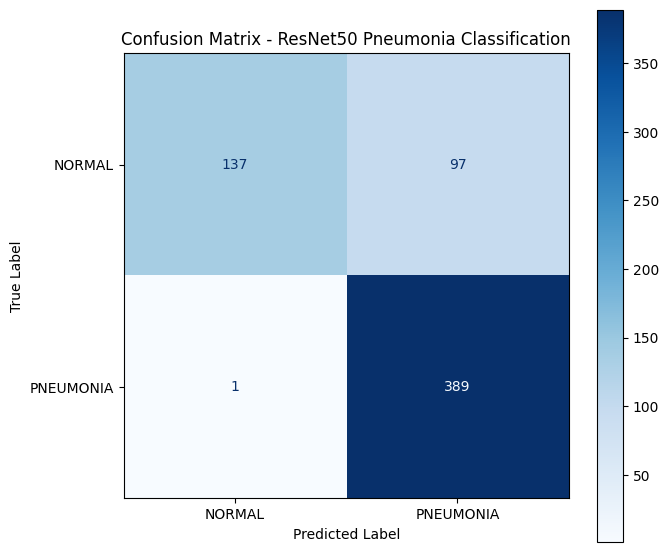

In [18]:
model.eval()

all_test_predictions = []
all_test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_test_predictions.extend(predictions.cpu().numpy())
        all_test_labels.extend(labels.numpy())

cm = confusion_matrix(all_test_labels, all_test_predictions)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        all_test_labels,
        all_test_predictions,
        target_names=["NORMAL", "PNEUMONIA"],
        digits=4
    )
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=np.asarray(cm),
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Confusion Matrix - ResNet50 Pneumonia Classification")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Experiment 1 — Training Curves

Training and validation curves are used to examine how Experiment 1 behaves throughout training.

The following metrics are visualized:

- **Training Loss**
- **Validation Loss**
- **Training F1-Score**
- **Validation F1-Score**

These curves help assess whether the model is learning consistently and whether there are signs of overfitting or divergence between training and validation performance.

The final plots are retained as project artifacts for documentation and analysis.

### Interpretation

The training history shows strong performance early in training, with both training and validation metrics providing evidence that the model learned useful representations from the chest X-ray images.

However, because the validation set used for model development is limited, the curves should be interpreted cautiously and should not be treated as definitive evidence of generalization to external clinical data.

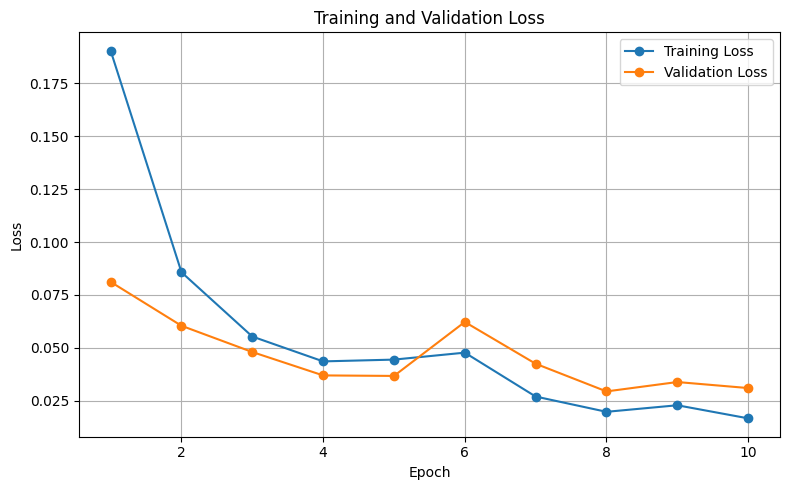

In [19]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Training Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("training_validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()

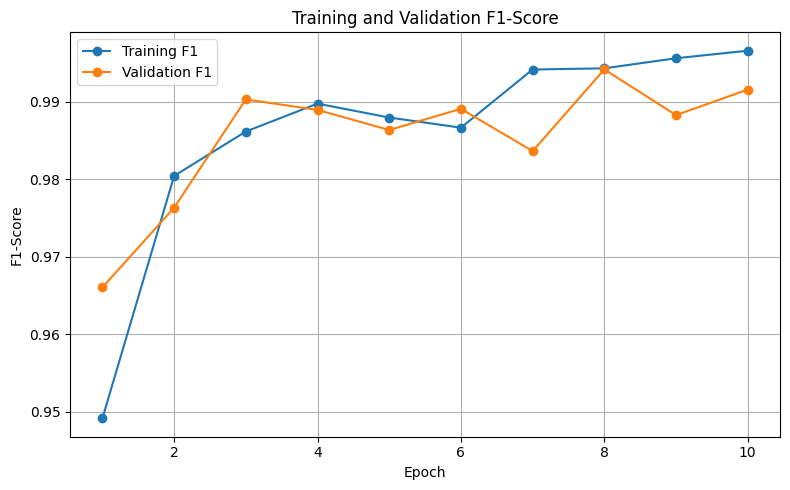

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_f1"], marker="o", label="Training F1")
plt.plot(epochs, history["val_f1"], marker="o", label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1-Score")
plt.title("Training and Validation F1-Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("training_validation_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
torch.save(
    best_model_weights,
    "resnet50_pneumonia_experiment1_best.pth"
)

print("Experiment 1 model saved successfully.")

Experiment 1 model saved successfully.


In [22]:
# Save the selected final model
torch.save(
    best_model_weights,
    "resnet50_pneumonia_final.pth"
)

# Save Experiment 1 training history
with open("experiment1_history.json", "w") as f:
    json.dump(history, f, indent=4)

print("Final model saved successfully.")
print("Experiment 1 history saved successfully.")

Final model saved successfully.
Experiment 1 history saved successfully.


## 14. Experiment 2 — Standard Cross-Entropy Loss

The second experiment uses the same **ResNet50 transfer-learning architecture** but trains the model using the standard **CrossEntropyLoss without class weighting**.

The purpose of this experiment is to provide a controlled comparison with Experiment 1.

### Experimental Design

The two experiments use the same overall model architecture and dataset pipeline. The main difference is the loss configuration:

| Experiment | Loss Function |
|---|---|
| Experiment 1 | Class-weighted CrossEntropyLoss |
| Experiment 2 | Standard CrossEntropyLoss |

This comparison helps evaluate whether explicitly compensating for class imbalance improves the model's overall classification performance.

### Experiment 2 Test Results

| Metric | Experiment 2 |
|---|---:|
| Test Loss | 0.8438 |
| Test Accuracy | 80.13% |
| Test Precision | 76.08% |
| Test Recall | 99.49% |
| Test F1-Score | 86.22% |

Experiment 2 also achieves very high pneumonia recall. However, compared with Experiment 1, it produces lower test accuracy, precision, and F1-score.

The results therefore provide evidence that the class-weighted training configuration used in Experiment 1 produced the stronger overall performance on this test set.

In [23]:
criterion_exp2 = nn.CrossEntropyLoss()

model_exp2 = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

model_exp2.fc = nn.Linear(
    in_features=2048,
    out_features=2
)

model_exp2 = model_exp2.to(device)

optimizer_exp2 = torch.optim.Adam(
    model_exp2.parameters(),
    lr=0.0001
)

scheduler_exp2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_exp2,
    mode="min",
    factor=0.1,
    patience=2
)

history_exp2 = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": []
}

best_val_f1_exp2 = 0.0
best_model_weights_exp2 = copy.deepcopy(model_exp2.state_dict())

print("Fresh ResNet50 created for Experiment 2.")

Fresh ResNet50 created for Experiment 2.


In [24]:
num_epochs_exp2 = 10

for epoch in range(num_epochs_exp2):

    train_loss, train_acc, train_precision, train_recall, train_f1 = train_one_epoch(
        model_exp2,
        new_train_loader,
        criterion_exp2,
        optimizer_exp2,
        device
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_exp2,
        new_val_loader,
        criterion_exp2,
        device
    )

    scheduler_exp2.step(val_loss)

    history_exp2["train_loss"].append(train_loss)
    history_exp2["val_loss"].append(val_loss)
    history_exp2["train_accuracy"].append(train_acc)
    history_exp2["val_accuracy"].append(val_acc)
    history_exp2["train_precision"].append(train_precision)
    history_exp2["val_precision"].append(val_precision)
    history_exp2["train_recall"].append(train_recall)
    history_exp2["val_recall"].append(val_recall)
    history_exp2["train_f1"].append(train_f1)
    history_exp2["val_f1"].append(val_f1)

    if val_f1 > best_val_f1_exp2:
        best_val_f1_exp2 = val_f1
        best_model_weights_exp2 = copy.deepcopy(model_exp2.state_dict())

    current_lr = optimizer_exp2.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch + 1}/{num_epochs_exp2}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"LR: {current_lr:.6f}"
    )

Epoch [1/10] | Train Loss: 0.1635 | Val Loss: 0.0576 | Train F1: 0.9601 | Val F1: 0.9865 | Val Recall: 0.9871 | LR: 0.000100
Epoch [2/10] | Train Loss: 0.0769 | Val Loss: 0.1374 | Train F1: 0.9806 | Val F1: 0.9549 | Val Recall: 0.9137 | LR: 0.000100
Epoch [3/10] | Train Loss: 0.0453 | Val Loss: 0.0436 | Train F1: 0.9900 | Val F1: 0.9871 | Val Recall: 0.9884 | LR: 0.000100
Epoch [4/10] | Train Loss: 0.0432 | Val Loss: 0.0894 | Train F1: 0.9887 | Val F1: 0.9755 | Val Recall: 1.0000 | LR: 0.000100
Epoch [5/10] | Train Loss: 0.0300 | Val Loss: 0.0695 | Train F1: 0.9924 | Val F1: 0.9789 | Val Recall: 0.9588 | LR: 0.000100
Epoch [6/10] | Train Loss: 0.0349 | Val Loss: 0.0369 | Train F1: 0.9922 | Val F1: 0.9917 | Val Recall: 0.9948 | LR: 0.000100
Epoch [7/10] | Train Loss: 0.0244 | Val Loss: 0.0441 | Train F1: 0.9942 | Val F1: 0.9870 | Val Recall: 0.9768 | LR: 0.000100
Epoch [8/10] | Train Loss: 0.0219 | Val Loss: 0.1047 | Train F1: 0.9955 | Val F1: 0.9743 | Val Recall: 0.9510 | LR: 0.000100


In [25]:
model_exp2.load_state_dict(best_model_weights_exp2)

test_loss_exp2, test_accuracy_exp2, test_precision_exp2, test_recall_exp2, test_f1_exp2 = evaluate(
    model_exp2,
    test_loader,
    criterion_exp2,
    device
)

print("EXPERIMENT 2 - FINAL TEST RESULTS")
print("----------------------------------")
print(f"Test Loss:      {test_loss_exp2:.4f}")
print(f"Test Accuracy:  {test_accuracy_exp2:.4f}")
print(f"Test Precision: {test_precision_exp2:.4f}")
print(f"Test Recall:    {test_recall_exp2:.4f}")
print(f"Test F1-Score:  {test_f1_exp2:.4f}")

EXPERIMENT 2 - FINAL TEST RESULTS
----------------------------------
Test Loss:      0.8859
Test Accuracy:  0.7917
Test Precision: 0.7510
Test Recall:    0.9974
Test F1-Score:  0.8568


## 15. Experiment Comparison

The two experiments are compared using their final test-set performance.

| Metric | Experiment 1 | Experiment 2 |
|---|---:|---:|
| Test Loss | 0.6628 | 0.8438 |
| Test Accuracy | 82.69% | 80.13% |
| Test Precision | 78.43% | 76.08% |
| Test Recall | 99.74% | 99.49% |
| Test F1-Score | 87.81% | 86.22% |

### Comparison

Experiment 1 achieves the stronger overall performance across the main classification metrics:

- **Accuracy:** 82.69% vs. 80.13%
- **Precision:** 78.43% vs. 76.08%
- **Recall:** 99.74% vs. 99.49%
- **F1-Score:** 87.81% vs. 86.22%

Both experiments maintain extremely high pneumonia recall. However, Experiment 1 provides better overall balance between precision and recall and achieves the higher F1-score.

### Selected Model

Based on the held-out test results, **Experiment 1 is selected as the final model configuration** for this project.

The selection is based primarily on its higher test accuracy and F1-score, while maintaining extremely high pneumonia recall.

The comparison demonstrates the impact of handling class imbalance through class-weighted loss in this experimental setting.

In [26]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Experiment 1 - Weighted Loss": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ],
    "Experiment 2 - Standard Loss": [
        test_accuracy_exp2,
        test_precision_exp2,
        test_recall_exp2,
        test_f1_exp2
    ]
})

display(results)

results.to_csv(
    "model_experiment_comparison.csv",
    index=False
)

print("Experiment comparison saved successfully.")

,Metric,Experiment 1 - Weighted Loss,Experiment 2 - Standard Loss
0,Accuracy,0.842949,0.791667
1,Precision,0.800412,0.750965
2,Recall,0.997436,0.997436
3,F1-Score,0.888128,0.856828


Experiment comparison saved successfully.


## 16. Image Statistics

Basic pixel-level statistics are calculated to characterize the image intensity distribution in the dataset.

A sample of **200 training images** and **200 test images** is analyzed.

### Sample Statistics

| Dataset | Images Analyzed | Average Pixel Mean | Average Pixel Std |
|---|---:|---:|---:|
| Training | 200 | 120.08 | 61.68 |
| Test | 200 | 125.50 | 60.31 |

The training and test samples show relatively similar average pixel statistics, although small differences are present.

These statistics provide a basic quantitative description of the image data and help identify potential distribution differences between the training and test samples.

The analysis is based on a sample of images and should therefore be interpreted as a descriptive dataset analysis rather than a complete statistical characterization of the entire dataset.

In [27]:
def analyze_images(dataset_samples, name, num_samples=200):
    sizes = []
    mean_values = []
    std_values = []

    samples = dataset_samples[:num_samples]

    for path, label in samples:
        image = Image.open(path).convert("L")
        sizes.append(image.size)

        array = np.array(image, dtype=np.float32)
        mean_values.append(array.mean())
        std_values.append(array.std())

    print(f"\n{name}")
    print("-" * 30)
    print("Images analyzed:", len(samples))
    print("Common sizes:", Counter(sizes).most_common(5))
    print(f"Average pixel mean: {np.mean(mean_values):.2f}")
    print(f"Average pixel std:  {np.mean(std_values):.2f}")


analyze_images(train_dataset.samples, "TRAINING DATA")
analyze_images(test_dataset.samples, "TEST DATA")


TRAINING DATA
------------------------------
Images analyzed: 200
Common sizes: [((2090, 1858), 1), ((1422, 1152), 1), ((1810, 1434), 1), ((1618, 1279), 1), ((1600, 1125), 1)]
Average pixel mean: 120.08
Average pixel std:  61.68

TEST DATA
------------------------------
Images analyzed: 200
Common sizes: [((2517, 1979), 2), ((1304, 952), 2), ((1168, 824), 2), ((1857, 1317), 1), ((2111, 1509), 1)]
Average pixel mean: 125.50
Average pixel std:  60.31


## 17. Confidence and Error Analysis

Beyond aggregate performance metrics, the model's predictions are examined to better understand its behavior on individual test images.

Confidence and error analysis helps identify cases where the model:

- Makes highly confident predictions.
- Produces incorrect predictions.
- Shows uncertainty between the two classes.
- May exhibit systematic prediction tendencies.

This analysis is particularly important for this project because the model achieves very high pneumonia recall while also producing a substantial number of false-positive predictions for NORMAL images.

Examining individual predictions therefore provides additional insight that cannot be obtained from accuracy, precision, recall, and F1-score alone.

In [28]:
model.load_state_dict(best_model_weights)
model.eval()

normal_confidences = []
pneumonia_confidences = []

normal_correct = 0
normal_total = 0
pneumonia_correct = 0
pneumonia_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)
        predictions = torch.argmax(probabilities, dim=1)
        confidence = probabilities.max(dim=1).values

        for label, prediction, conf in zip(
            labels,
            predictions.cpu(),
            confidence.cpu()
        ):
            if label.item() == 0:
                normal_total += 1
                if prediction.item() == 0:
                    normal_correct += 1
                    normal_confidences.append(conf.item())
            else:
                pneumonia_total += 1
                if prediction.item() == 1:
                    pneumonia_correct += 1
                    pneumonia_confidences.append(conf.item())

print("NORMAL")
print("Correct:", normal_correct, "/", normal_total)
print("Average confidence on correct predictions:",
      round(np.mean(normal_confidences), 4))

print("\nPNEUMONIA")
print("Correct:", pneumonia_correct, "/", pneumonia_total)
print("Average confidence on correct predictions:",
      round(np.mean(pneumonia_confidences), 4))

NORMAL
Correct: 137 / 234
Average confidence on correct predictions: 0.8891

PNEUMONIA
Correct: 389 / 390
Average confidence on correct predictions: 0.9976


In [29]:
false_positive_confidences = []
false_negative_confidences = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)
        predictions = torch.argmax(probabilities, dim=1)
        confidence = probabilities.max(dim=1).values

        for label, prediction, conf in zip(
            labels,
            predictions.cpu(),
            confidence.cpu()
        ):
            if label.item() == 0 and prediction.item() == 1:
                false_positive_confidences.append(conf.item())
            elif label.item() == 1 and prediction.item() == 0:
                false_negative_confidences.append(conf.item())

print("NORMAL → PNEUMONIA errors:", len(false_positive_confidences))

if false_positive_confidences:
    print("Average confidence:",
          round(np.mean(false_positive_confidences), 4))
    print("Minimum confidence:",
          round(np.min(false_positive_confidences), 4))
    print("Maximum confidence:",
          round(np.max(false_positive_confidences), 4))

print("\nPNEUMONIA → NORMAL errors:", len(false_negative_confidences))

if false_negative_confidences:
    print("Average confidence:",
          round(np.mean(false_negative_confidences), 4))

NORMAL → PNEUMONIA errors: 97
Average confidence: 0.8834
Minimum confidence: 0.5125
Maximum confidence: 1.0

PNEUMONIA → NORMAL errors: 1
Average confidence: 0.9974


## 18. False-Positive Visualization

False-positive predictions are examined by visualizing NORMAL chest X-rays that were incorrectly classified as PNEUMONIA.

The final confusion matrix shows **107 false-positive predictions** among the 234 NORMAL test images.

This analysis is important because it highlights the main weakness of the selected model: although it detects pneumonia cases with extremely high recall, it can incorrectly flag normal images as pneumonia.

Visualizing these cases provides qualitative evidence of the model's error behavior and helps identify the need for improved specificity and external validation in future work.

False-positive NORMAL images: 97


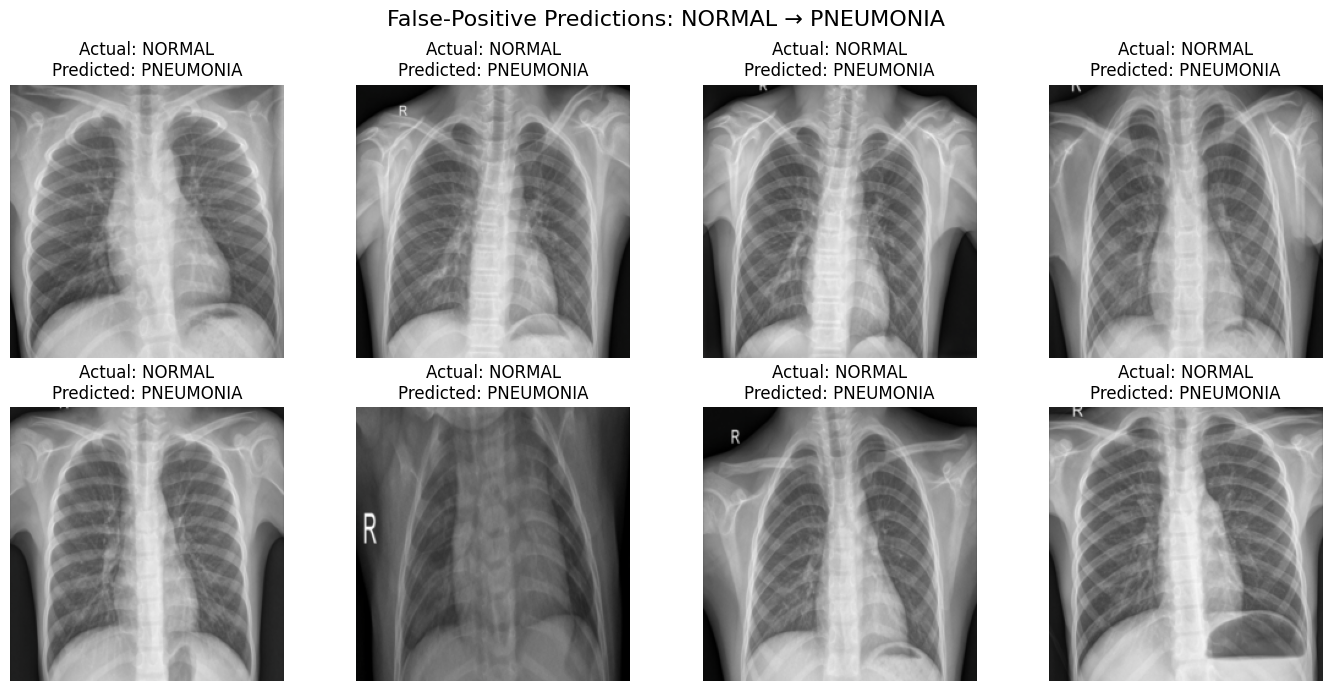

In [30]:
false_positive_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        for i in range(len(labels)):
            if labels[i].item() == 0 and predictions[i].item() == 1:
                false_positive_images.append(
                    (
                        images[i].cpu(),
                        labels[i].item(),
                        predictions[i].item()
                    )
                )

print("False-positive NORMAL images:", len(false_positive_images))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, (image, label, prediction) in zip(
    axes.flatten(),
    false_positive_images[:8]
):
    image = image.permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title("Actual: NORMAL\nPredicted: PNEUMONIA")
    ax.axis("off")

plt.suptitle(
    "False-Positive Predictions: NORMAL → PNEUMONIA",
    fontsize=16
)
plt.tight_layout()
plt.show()

## 19. Save Final Project Artifacts

The final project artifacts are saved to preserve the trained models, experiment results, training history, evaluation outputs, and visualizations.

### Saved Artifacts

The project produces the following files:

| Artifact | Purpose |
|---|---|
| `resnet50_pneumonia_final.pth` | Final trained ResNet50 model |
| `resnet50_pneumonia_experiment1_best.pth` | Best Experiment 1 model |
| `experiment1_history.json` | Experiment 1 training history |
| `model_experiment_comparison.csv` | Comparison of Experiment 1 and Experiment 2 |
| `confusion_matrix.png` | Final Experiment 1 confusion matrix |
| `training_validation_f1.png` | Training and validation F1-score curves |
| `training_validation_loss.png` | Training and validation loss curves |
| `pneumonia_resnet50_artifacts.zip` | ZIP archive containing the project artifacts |

These files provide the necessary materials for reproducibility, further analysis, portfolio presentation, and future research work.

In [31]:
import os

output_files = [
    "resnet50_pneumonia_final.pth",
    "resnet50_pneumonia_experiment1_best.pth",
    "experiment1_history.json",
    "model_experiment_comparison.csv",
    "confusion_matrix.png",
    "training_validation_loss.png",
    "training_validation_f1.png"
]

print("PROJECT ARTIFACT VERIFICATION")
print("=" * 60)

all_found = True

for file in output_files:
    exists = os.path.exists(file)
    print(f"{file:45} {'FOUND' if exists else 'MISSING'}")
    if not exists:
        all_found = False

print("=" * 60)

if all_found:
    print("All 7 individual artifacts are present.")
else:
    print("WARNING: One or more artifacts are missing.")

PROJECT ARTIFACT VERIFICATION
resnet50_pneumonia_final.pth                  FOUND
resnet50_pneumonia_experiment1_best.pth       FOUND
experiment1_history.json                      FOUND
model_experiment_comparison.csv               FOUND
confusion_matrix.png                          FOUND
training_validation_loss.png                  FOUND
training_validation_f1.png                    FOUND
All 7 individual artifacts are present.


In [32]:
import os
import zipfile

artifacts = [
    "resnet50_pneumonia_final.pth",
    "resnet50_pneumonia_experiment1_best.pth",
    "experiment1_history.json",
    "model_experiment_comparison.csv",
    "confusion_matrix.png",
    "training_validation_loss.png",
    "training_validation_f1.png"
]

zip_path = "/kaggle/working/pneumonia_resnet50_artifacts.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in artifacts:
        file_path = os.path.join("/kaggle/working", file)
        if os.path.exists(file_path):
            zipf.write(file_path, arcname=file)
            print(f"Added: {file}")
        else:
            print(f"NOT FOUND: {file}")

print("\nZIP CREATED:")
print(zip_path)
print(f"Size: {os.path.getsize(zip_path) / (1024 * 1024):.2f} MB")

Added: resnet50_pneumonia_final.pth
Added: resnet50_pneumonia_experiment1_best.pth
Added: experiment1_history.json
Added: model_experiment_comparison.csv
Added: confusion_matrix.png
Added: training_validation_loss.png
Added: training_validation_f1.png

ZIP CREATED:
/kaggle/working/pneumonia_resnet50_artifacts.zip
Size: 167.55 MB


## 20. Final Output Check

Before finalizing the project, the saved artifacts are checked to confirm that the required files were successfully generated.

The final verification ensures that:

- The trained model files exist.
- The experiment history is available.
- The experiment comparison file is available.
- The confusion matrix is available.
- Training and validation plots are available.
- The complete artifact ZIP archive is available.

This verification step helps ensure that the final notebook can be preserved and shared without losing important project outputs.

In [33]:
output_files = [
    "resnet50_pneumonia_final.pth",
    "resnet50_pneumonia_experiment1_best.pth",
    "experiment1_history.json",
    "model_experiment_comparison.csv",
    "confusion_matrix.png",
    "training_validation_loss.png",
    "training_validation_f1.png"
]

print("PROJECT OUTPUT FILES")
print("-" * 40)

for file in output_files:
    print(f"{file}: {'FOUND' if os.path.exists(file) else 'MISSING'}")

PROJECT OUTPUT FILES
----------------------------------------
resnet50_pneumonia_final.pth: FOUND
resnet50_pneumonia_experiment1_best.pth: FOUND
experiment1_history.json: FOUND
model_experiment_comparison.csv: FOUND
confusion_matrix.png: FOUND
training_validation_loss.png: FOUND
training_validation_f1.png: FOUND


In [34]:
import os

print("Files currently in /kaggle/working/:")
print("=" * 50)

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        print(os.path.join(root, file))

Files currently in /kaggle/working/:
/kaggle/working/confusion_matrix.png
/kaggle/working/training_validation_loss.png
/kaggle/working/model_experiment_comparison.csv
/kaggle/working/__notebook__.ipynb
/kaggle/working/experiment1_history.json
/kaggle/working/pneumonia_resnet50_artifacts.zip
/kaggle/working/resnet50_pneumonia_experiment1_best.pth
/kaggle/working/resnet50_pneumonia_final.pth
/kaggle/working/training_validation_f1.png


## 21. Conclusion

This project developed a **ResNet50-based deep learning model for binary chest X-ray classification**, distinguishing between **NORMAL** and **PNEUMONIA** cases using transfer learning.

Two experiments were conducted to investigate the effect of handling class imbalance during training. Experiment 1 used a **class-weighted CrossEntropyLoss**, while Experiment 2 used the standard CrossEntropyLoss.

Based on the held-out test results, **Experiment 1 was selected as the final model configuration**.

### Final Performance

Experiment 1 achieved:

- **Accuracy:** 82.69%
- **Precision:** 78.43%
- **Recall:** 99.74%
- **F1-Score:** 87.81%

The model demonstrated particularly strong sensitivity toward pneumonia cases. Only **1 of 390 pneumonia cases** in the test set was classified as NORMAL.

However, the model also produced **107 false-positive predictions** among the 234 NORMAL test images. This indicates that the model's strong pneumonia sensitivity comes with a reduction in its ability to correctly distinguish normal cases.

Therefore, the results should be interpreted as a research and educational demonstration of transfer learning for medical image classification rather than as evidence of clinical readiness.

The project provides a complete experimental workflow covering dataset analysis, preprocessing, transfer learning, controlled experimentation, evaluation, error analysis, and artifact preservation.

## 22. Limitations

Several limitations should be considered when interpreting the results of this project.

### 1. Class Imbalance

The original training dataset contains substantially more PNEUMONIA images than NORMAL images. Although class-weighted loss was investigated in Experiment 1, class imbalance can still influence model behavior.

### 2. Small Original Validation Set

The original validation directory contains only **16 images**. A stratified validation split was therefore created from the training data, but the limited validation data remains a constraint when assessing generalization.

### 3. False-Positive Predictions

The final model produces a relatively high number of false-positive predictions for NORMAL images. The confusion matrix shows **107 NORMAL images classified as PNEUMONIA**.

Improving specificity and reducing false positives is an important direction for future work.

### 4. Dataset and Domain Variability

Chest X-ray images can vary substantially across hospitals, imaging equipment, patient populations, acquisition protocols, and disease presentation. Performance on this dataset may therefore not generalize to other clinical environments.

### 5. External Validation

The model has not been evaluated on an independent external clinical dataset. External validation would be necessary before making claims about broader generalization.

### 6. Clinical Use

This project is intended for **research and educational purposes only**. It is not a clinical diagnostic system and should not be used to make medical decisions.

## 23. Future Work

Several improvements could be investigated in future research.

### Model and Training Improvements

- Evaluate additional pretrained architectures.
- Tune the classification threshold to investigate the trade-off between sensitivity and specificity.
- Explore methods for reducing false-positive predictions.
- Perform more systematic hyperparameter optimization.

### Dataset Improvements

- Evaluate the model on larger and more diverse datasets.
- Perform external validation using an independent dataset.
- Investigate dataset quality, labeling consistency, and domain shift.

### Explainability

Future work could incorporate explainability methods such as **Grad-CAM** to investigate which regions of a chest X-ray contribute most strongly to the model's predictions.

### Medical Image Segmentation

A natural progression from this classification project is **medical image segmentation**, where the goal is not only to classify an X-ray but also to localize or segment abnormal regions.

This creates a potential research progression:

**Classification → Localization → Segmentation**

The current project therefore provides a foundation for future work in medical image analysis and computer-aided diagnosis research.

## 24. Project Summary

| Component | Final Project |
|---|---|
| Task | Binary chest X-ray classification |
| Classes | NORMAL / PNEUMONIA |
| Architecture | ResNet50 |
| Approach | Transfer Learning |
| Experiments | 2 |
| Selected Experiment | Experiment 1 |
| Test Accuracy | 82.69% |
| Test Precision | 78.43% |
| Test Recall | 99.74% |
| Test F1-Score | 87.81% |
| Primary Strength | High pneumonia sensitivity |
| Primary Limitation | High false-positive rate for NORMAL images |

The project demonstrates an end-to-end deep learning workflow for medical image classification, from dataset exploration and preprocessing to transfer learning, controlled experimentation, evaluation, error analysis, and artifact preservation.